# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** Track A: Standard Analysis Project

**Group members:** 

- Victor Bjerggaard Thøstesen
- Nikolai Mose Sannerum  
- Frederik Hansen Baattrup  

**Dataset:** 

During the project we look at game statistics for Premier league matches since 2005. The datasets from 2003/2004 and 2004/2005 seasons are disregarded due to reading issues. 

Some features of the full datasets are combined into a master dataframe. This dataframe contains the features: "HomeTeam", "AwayTeam", "Full Time Result (FTR)", "Referee", "Full Time Home Goal (FTHG)", "Full Time Away Goal (FTAG)", "Home Shots (HS)", "Away Shots (AS)", "Home Shots On Target (HST)", "Away Shots On Target (AST)", "Home Fouls (HF)", "Away Fouls (AF)", "Home Corner (HC)", "Away Corner (AC)", "Home Yellow (HY)", "Away Yellow (Ay)", "Home Red (HR)", "Away Red (AR)", "Average Home Win Odds (AvgH)", "Average Draw Odds (AvgD)", "Average Away Win Odds (AvgA)", "Date" and "Season".

**Initial task description (Module 1 perspective):**

For the first part of the project we want to analyze our dataset using clustering. Our tentative analysis goal is to pick out a set of features from the dataset which can be meaningfully clustered and compared to a ground truth. First we apply unsupervised clustering to group football matches using in game statistics. The chosen features will be combined and transformed in order to reduce dimensions and make the matches more comparable. Outcome-related variables FTHG, FTAG, FTR, HTR and odds are excluded from clustering to prevent data leak and reserved for evaluation. After normalizing the numeric features, clustering algorithms are applied to identify match groupings. The FTR column serves as ground truth to assess alignment between clusters and actual outcomes (home win, away win, draw). Cluster evaluation metrics includes contingency tables and cluster purity measurements.


## 0. Reproducibility and Setup

In [2]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.14.2 (main, Dec  5 2025, 16:49:16) [Clang 17.0.0 (clang-1700.6.3.2)]


## 1. Dataset Description and Loading

### Dataset Overview

- Source: https://www.football-data.co.uk/englandm.php?fbclid=IwY2xjawQVBq9leHRuA2FlbQIxMABicmlkETBhSDJ4V01maU9aZVJ1dkNsc3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHr9Bnmq21fRPvCUMfkcBIu9edZEMLrEi-QTbB8sBlRDK8vETlRUAA3XgndZg_aem_OCN-0ddvAe0Fob_1GlxMdg

- Number of instances (matches): 7860
- Number of features / entities: 23
- Missing values: No missing values after preprocessing. However when the seasons were combined we used only the average odds (provided by different websites for different seasons).


In [3]:
# --- Data Extraction Function ---
# Here we define a function to extract the chosen relevant data features from the raw CSV files.
# This function will look for the average odds columns and handle cases where they might be missing.

def extract_data(df, filename):
    """
    Extracts average in game features and home/draw/away odds from CSV file.
    Prefers BbAvH/D/A, otherwise falls back to AvgH/D/A.
    Adds season column extracted from filename.

    parameters:
    df: DataFrame containing the raw data from the CSV file.
    filename: The name of the CSV file, used to extract the season information.

    return: A DataFrame with the extracted features and season information, or None if required columns are missing.

    """

    primary_cols = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                  'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "BbAvH", "BbAvD", "BbAvA", 'Date']
    fallback_cols = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                  'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "AvgH", "AvgD", "AvgA", 'Date']

    season = os.path.splitext(filename)[0]

    # Trying to find Betbrain columns first
    if all(col in df.columns for col in primary_cols):
        result = df[primary_cols].copy()
        result.columns = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                            'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                            'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "AvgH", "AvgD", "AvgA", 'Date']
        print(f'Found primary columns: BbAvH, BbAvD, BbAvA for {filename}')

    # Else trying to find fallback columns
    elif all(col in df.columns for col in fallback_cols):
        result = df[fallback_cols].copy()
        print(f'Using fallback columns: AvgH, AvgD, AvgA for {filename}')

    # If neither set of columns is found, print a warning and return None
    else:
        print(f"⚠ Warning: Required odds columns not found in {filename}")
        return None

    # Add season column
    result["Season"] = season
    
    return result

In [4]:
# --- User settings begin ---
dataPath = "Data" # Define the folder where the raw CSV files are located.
# --- User settings end ---

new_data = []

for file in os.listdir(dataPath):
    if file.endswith(".csv"):
        path = os.path.join(dataPath, file)
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"⚠ Error reading {file}: {e}")
            continue

        extracted = extract_data(df, file)

        if extracted is not None:
            new_data.append(extracted)

# Combine everything into one dataframe
final_df = pd.concat(new_data, ignore_index=True)

Found primary columns: BbAvH, BbAvD, BbAvA for 20072008premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20112012premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20132014premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20242025premierleague.csv
⚠ Error reading 20042005premierleague.csv: 'utf-8' codec can't decode byte 0xa0 in position 75614: invalid start byte
Using fallback columns: AvgH, AvgD, AvgA for 20202021premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20192020premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20082009premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20062007premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20152016premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20222023premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20102011premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20092010premierleague.csv
Found primary 

In [5]:
print(f"\n Final dataset:")
final_df = final_df.dropna(subset=["HomeTeam", "AwayTeam"]) # 2014/2015 season has a row of NaN that is removed here
final_df


 Final dataset:


,HomeTeam,AwayTeam,FTR,Referee,FTHG,FTAG,HS,AS,HST,AST,...,AC,HY,AY,HR,AR,AvgH,AvgD,AvgA,Date,Season
0,Aston Villa,Liverpool,A,M Riley,1.0,2.0,10.0,17.0,6.0,7.0,...,2.0,4.0,2.0,0.0,0.0,3.67,3.23,1.95,11/08/07,20072008premierleague
1,Bolton,Newcastle,A,C Foy,1.0,3.0,13.0,7.0,9.0,5.0,...,3.0,1.0,1.0,0.0,0.0,2.41,3.18,2.80,11/08/07,20072008premierleague
2,Derby,Portsmouth,D,M Dean,2.0,2.0,12.0,12.0,5.0,6.0,...,6.0,1.0,2.0,0.0,0.0,2.85,3.19,2.38,11/08/07,20072008premierleague
3,Everton,Wigan,H,M Clattenburg,2.0,1.0,12.0,14.0,8.0,4.0,...,2.0,0.0,0.0,0.0,0.0,1.66,3.45,5.25,11/08/07,20072008premierleague
4,Middlesbrough,Blackburn,A,A Marriner,1.0,2.0,10.0,4.0,6.0,4.0,...,3.0,3.0,4.0,0.0,0.0,2.41,3.18,2.81,11/08/07,20072008premierleague
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7855,Hull,Man United,D,L Probert,0.0,0.0,16.0,7.0,6.0,1.0,...,1.0,2.0,2.0,0.0,1.0,3.14,3.55,2.21,24/05/15,20142015premierleague
7856,Leicester,QPR,H,M Oliver,5.0,1.0,22.0,18.0,7.0,2.0,...,6.0,0.0,0.0,0.0,0.0,1.56,4.21,5.71,24/05/15,20142015premierleague
7857,Man City,Southampton,H,C Foy,2.0,0.0,15.0,13.0,6.0,4.0,...,4.0,1.0,1.0,0.0,0.0,1.56,4.27,5.61,24/05/15,20142015premierleague
7858,Newcastle,West Ham,H,M Atkinson,2.0,0.0,17.0,4.0,4.0,1.0,...,3.0,2.0,1.0,0.0,0.0,1.77,3.84,4.42,24/05/15,20142015premierleague


In [6]:
def encode_results(results):
    """
    Endcoding of results
    1: HOME WIN, -1: AWAY WIN, 0: DRAW

    parameters:
    results (list of dicts): results to encode 

    returns:
    encoding (numpy array): encoded results
    """
    encoding = np.zeros(len(results)) # Initialize encoding array

    for i in range(len(results)):
        if results[i] == "H":
            encoding[i] = 1 # Home win
        elif results[i] == "A":
            encoding[i] = -1 # Away win
        else:
            encoding[i] = 0 # Draw
    return encoding
data = final_df.copy()
ground_truth = encode_results(data['FTR'])
print("Amount of home wins: ", np.sum(ground_truth == 1))
print("Amount of away wins: ", np.sum(ground_truth == -1))
print("Amount of draws: ", np.sum(ground_truth == 0))

Amount of home wins:  3586
Amount of away wins:  2368
Amount of draws:  1906


In [7]:
#---- Computing table of points----
def compute_points_table(df):
    # Get all unique teams
    teams = pd.unique(df[['HomeTeam', 'AwayTeam']].values.ravel())
    
    # Initialize points dictionary
    points = {team: 0 for team in teams}
    
    # Iterate over matches
    for _, row in df.iterrows():
        if row['FTR'] == 'H':
            points[row['HomeTeam']] += 3
        elif row['FTR'] == 'A':
            points[row['AwayTeam']] += 3
        elif row['FTR'] == 'D':
            points[row['HomeTeam']] += 1
            points[row['AwayTeam']] += 1

    # Convert to sorted list (like standings)
    sorted_points = sorted(points.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_points


#---- Normalizing table of points----
def normalize_points(points_table):
    """
    points_table: list of tuples (team, points)
    returns: list of tuples (team, normalized_score)
    """
    total_points = sum(points for _, points in points_table)
    
    normalized = [(team, points / total_points) for team, points in points_table]
    
    return normalized


## Module 2 — Graph-Based Analysis

The networkx graph has been made as an directed graph, where the nodes are teams, while the edges are matches that points to the winning team, weighted by goal difference. If draw, the match is discarded, and if the same team win several matches, these matches are compressed into a single edge with the total goal difference as weight.

From the graph we construct an adjacency matrix where the [i, j] entry is the weight of the team j winning against team i. Note that entries with zeros correspond to either draws or a team that didn't win in any match. The teams are sorted in alphabetic order.

<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.S

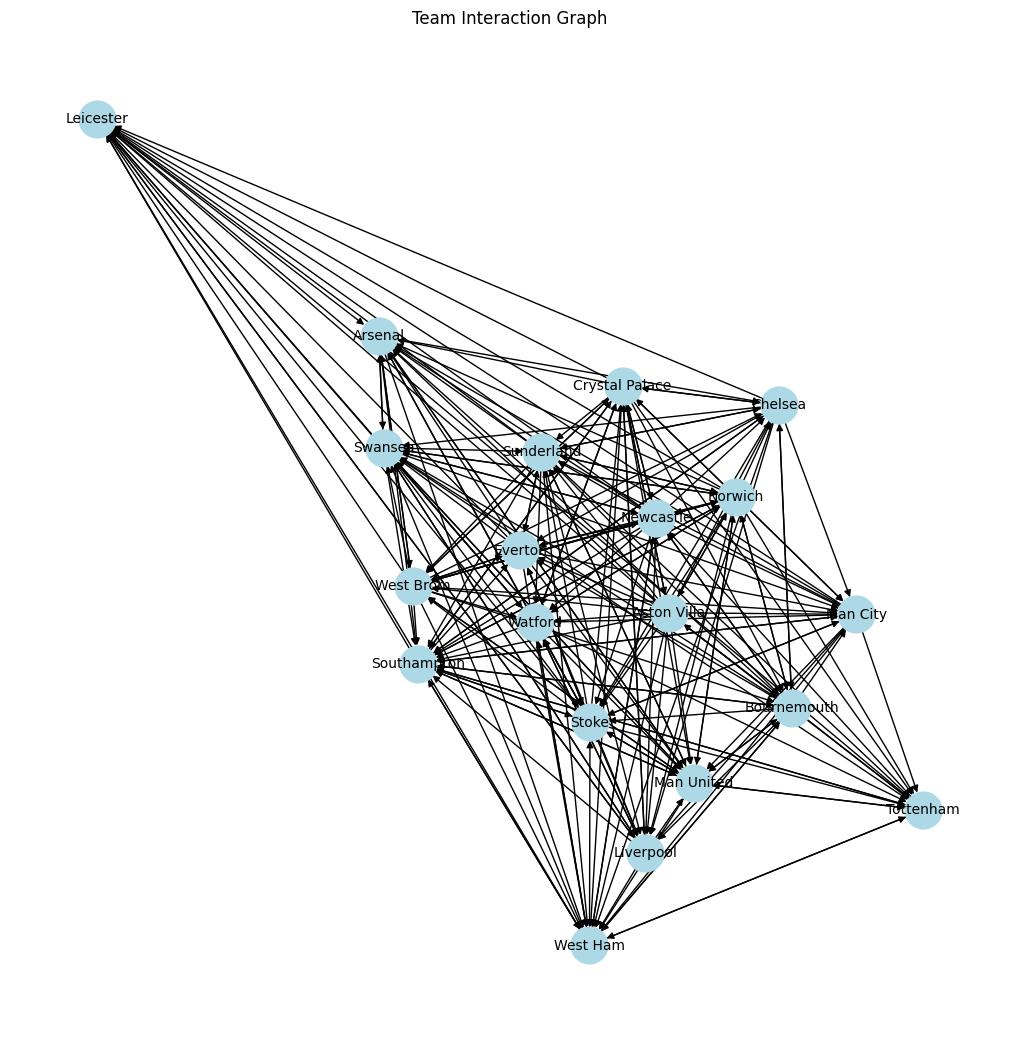

In [15]:
class DiG_edge:
    """Wrapper class for graph edges, containing source, target, and weight."""
    def __init__(self, Source: str, Target: str, weight: float):
        self.Source = Source
        self.Target = Target 
        self.weight = weight 

def weight_function(row, hyperparams):
    """
    Computes a weighted score for a match based on various statistics and the provided hyperparameters.
    The score is positive for the winning team with the graph edge directed from the losing team to the winning team.
    parameters:
        row: A row from the DataFrame containing match statistics.
        hyperparams: A list of weights for each statistic.

    returns:
        DiG_edge: An object containing the source team, target team, and the computed weight for the graph edge.    
    """
    print(type(row))
    stats = np.array([
        row['FTHG'] - row['FTAG'],
        row['HS'] - row['AS'],     
        row['HST'] - row['AST'],   
        row['AF'] - row['HF'],   # Its bad to have more fouls than the opponent, so we subtract home from away  
        row['HC'] - row['AC'],     
        row['AY'] - row['HY'],  # More yellow cards than the opponent is bad, so we subtract home from away
        row['AR'] - row['HR'],     # More red cards than the opponent is bad, so we subtract home from away  
        row['AvgH'] - row['AvgA']
    ])
    # --- Normalization ---
    stats = stats / np.linalg.norm(stats)
    weighted_score = np.sum(stats * hyperparams)
    
    if weighted_score > 0:
        return DiG_edge(row['AwayTeam'], row['HomeTeam'], weighted_score)
    elif weighted_score < 0:
        return DiG_edge(row['HomeTeam'], row['AwayTeam'], -weighted_score)
    else:
        return None

def create_and_plot_graph(edges: pd.Series, plot: bool = True):
    """
    Creates a directed graph from a Series of DiG_edge objects, where edges represent wins
    and are weighted by the computed score.

    parameters:
    edges (pd.Series): Series of DiG_edge objects (can contain None for draws/zero scores)
    plot (bool): Whether to plot the graph

    returns:
    G (DiGraph): Directed graph representing team interactions
    """
    # Filter out None values
    edges = [e for e in edges if e is not None]

    # Build DataFrame from edges
    edge_df = pd.DataFrame({
        'Source': [e.Source for e in edges],
        'Target': [e.Target for e in edges],
        'weight': [e.weight for e in edges]
    })

    # Aggregate weights if multiple edges exist between same teams
    edge_df = edge_df.groupby(['Source', 'Target'], as_index=False)['weight'].sum()

    # Build directed graph
    G = nx.from_pandas_edgelist(
        edge_df,
        source='Source',
        target='Target',
        edge_attr='weight',
        create_using=nx.DiGraph()
    )

    # Plot
    if plot:
        plt.figure(figsize=(10, 10))
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10)
        plt.title('Team Interaction Graph')
        plt.show()

    return G

# --- Usage ---
hyperparams = [1, 0, 0, 0, 0, 0, 0, 0]  # Only goal difference matters
weightGd = data.apply(lambda row: weight_function(row, hyperparams), axis=1)

# **Call the graph function only with the Series of DiG_edge**
G = create_and_plot_graph(weightGd)

In [9]:
# --- Construct the transition matrix ---
def construct_transition_matrix(G):
    A = nx.to_numpy_array(G, weight='weight', nodelist=sorted(G.nodes()))
    Delta = np.diag(A.sum(axis=1)) # Degree matrix (sum of rows)
    M = A.T @ np.linalg.inv(Delta) # Transition matrix (By O8-LinkAnalysis slide 19)
    return M

# --- Finding page rank by power iteration ---
def power_iteration(M, num_simulations: int, alpha: float = 0.85, tol: float = 1e-6):
    """
    Power iteration method to find the dominant eigenvector of matrix M.
    (By O8-LinkAnalysis slide 22)

    parameters:
    M (numpy array): The matrix for which to compute the dominant eigenvector.
    num_simulations (int): The number of iterations to perform.

    returns:
    numpy array: The dominant eigenvector of M, normalized to sum to 1.
    """
    # Start with uniform vector
    b_k = np.ones(M.shape[1]) / M.shape[1] 
    
    n = M.shape[0]
    E = np.ones((n, n)) / n
    new_M = alpha * M + (1 - alpha) * E

    for _ in range(num_simulations):
        # Calculate the matrix-by-vector product
        
        b_k1 = new_M @ b_k

        if np.linalg.norm(b_k1 - b_k, 1) < tol:
            break
        
        # Normalize the resulting vector
        b_k1_norm = np.linalg.norm(b_k1)
        if b_k1_norm == 0:
            return b_k1  # Avoid division by zero
        b_k = b_k1 / np.sum(b_k1) # Normalize to sum to 1
    
    return b_k / np.sum(b_k)  # Normalize to sum to 1

def M_to_sorted_by_pagerank(M, G):
    pagerank_vector = power_iteration(M, num_simulations=1000, tol=1e-6)
    pagerank_scores = {node: score for node, score in zip(sorted(G.nodes()), pagerank_vector)}
    sorted_teams = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_teams

def print_scores(sorted_teams):
    print("Scores:") 
    for team, score in sorted_teams:
        print(f"{team}: {score:.4f}")


In [10]:
M = construct_transition_matrix(G)       
myPageRank = M_to_sorted_by_pagerank(M, G)
print_scores(myPageRank)    

Scores:
Man City: 0.0719
Arsenal: 0.0661
Liverpool: 0.0657
Man United: 0.0655
Chelsea: 0.0651
Tottenham: 0.0580
Everton: 0.0478
Newcastle: 0.0410
West Ham: 0.0391
Aston Villa: 0.0373
Fulham: 0.0279
Leicester: 0.0235
Crystal Palace: 0.0232
Southampton: 0.0227
Brighton: 0.0220
Wolves: 0.0214
Bournemouth: 0.0200
West Brom: 0.0192
Stoke: 0.0188
Sunderland: 0.0182
Blackburn: 0.0169
Bolton: 0.0160
Wigan: 0.0156
Swansea: 0.0151
Brentford: 0.0147
Burnley: 0.0139
Watford: 0.0127
Nott'm Forest: 0.0110
Portsmouth: 0.0108
Middlesbrough: 0.0107
Leeds: 0.0093
Norwich: 0.0089
Reading: 0.0083
Hull: 0.0081
Birmingham: 0.0080
Sheffield United: 0.0078
Charlton: 0.0063
QPR: 0.0057
Cardiff: 0.0053
Huddersfield: 0.0047
Blackpool: 0.0046
Luton: 0.0040
Ipswich: 0.0039
Derby: 0.0035


This graph cares on how many goals you won a match where league table does not. this can probably be seen if checking 2015/2016 season where Leicester won.

Maybe there is some kind of data leak here since the analysis basically is based on full time result. Lets generalize how we calculate the weights and see if we can find some good weights that will reproduce the table. In a sense what in game stats is more important. We did gradient descent and found out that Gradient descent is the wrong tool when:

The loss surface is very flat near the starting point
The interesting region is far from initialisation
You have only 8 discrete-ish parameters
The Gradients become super small

We did random seach instead.

In [11]:
data = final_df.copy()[final_df['Season'] == '20242025premierleague']
data = final_df.copy()
hyperparams = [0, 1, 1, 1, 1, 1, 1, 0] 
weightGd = data.apply(lambda row: weight_function(row, hyperparams), axis=1)
G = create_and_plot_graph(weightGd, plot=False)
M = construct_transition_matrix(G)

sorted_teams = M_to_sorted_by_pagerank(M, G)
norm_pts = normalize_points(compute_points_table(data))

def evaluate(data, hyperparams, norm_pts):
    weightGd = data.apply(lambda row: weight_function(row, hyperparams), axis=1)
    G = create_and_plot_graph(weightGd, plot=False)
    M = construct_transition_matrix(G)
    pagerank_scores = M_to_sorted_by_pagerank(M, G) # List of tuples (team, pagerank_score) sorted by pagerank score
    dict_score = {team: score for team, score in pagerank_scores} # Dictionary for easy lookup
    points_dict = dict(norm_pts)
    teams = [t for t in dict_score if t in points_dict]
    return sum((dict_score[t] - points_dict[t])**2 for t in teams) / len(teams)


In [12]:
from itertools import product
import random
import tqdm

def random_search(data, norm_pts, n_trials=500, data_leak=False):
    best_loss = float('inf')
    best_params = None
    
    for _ in tqdm.tqdm(range(n_trials), desc="Random Search Trials"):
        # Sample each param from a wider range
        params = np.random.uniform(0, 5, size=8)
        if not data_leak:  # To avoid a data leak we put FTHG/FTAG diffrence and AvgH/AvgA diffrence weights to zero
            params[0] = 0
            params[7] = 0

        loss_val = evaluate(data, params, norm_pts)
        
        if loss_val < best_loss:
            best_loss = loss_val
            best_params = params.copy()
            print(f"New best gives loss: {best_loss:.6f}, params: {np.round(best_params, 3)}")
    return best_params, best_loss
norm_pts = normalize_points(compute_points_table(data))
print(norm_pts)
best_params, best_loss = random_search(data[data['Season'] == '20232024premierleague'], norm_pts, n_trials=10000) # We run random search only on the 2023/2024 season to avoid a data leak, since the points table is computed on all seasons.
print("Best Hyperparameters from Random Search:", best_params)

[('Man City', 0.07225246839531235), ('Liverpool', 0.07082218326105011), ('Man United', 0.07049921565008767), ('Chelsea', 0.07008397157885024), ('Arsenal', 0.0691612069761004), ('Tottenham', 0.06076404909107687), ('Everton', 0.05149026483344099), ('West Ham', 0.04230875703608009), ('Newcastle', 0.04221648057580511), ('Aston Villa', 0.04050936606071791), ('Fulham', 0.029482329057857342), ('Crystal Palace', 0.02689858817015779), ('Southampton', 0.023668912060533356), ('Leicester', 0.023253667989295932), ('Stoke', 0.02108517117283381), ('Wolves', 0.020900618252283842), ('Sunderland', 0.020300821260496447), ('West Brom', 0.01983943895912153), ('Brighton', 0.01896281258650918), ('Bournemouth', 0.01804004798375934), ('Burnley', 0.016932730460459535), ('Blackburn', 0.015594721786472272), ('Wigan', 0.015271754175509827), ('Swansea', 0.01439512780289748), ('Bolton', 0.014348989572759988), ('Watford', 0.012042078065885392), ('Brentford', 0.011073175232998063), ('Portsmouth', 0.01005813416997324),

Random Search Trials:   0%|          | 15/10000 [00:00<01:10, 142.11it/s]

New best gives loss: 0.000568, params: [0.    4.754 3.66  2.993 0.78  0.78  0.29  0.   ]
New best gives loss: 0.000555, params: [0.    2.476 0.172 4.547 1.294 3.313 1.559 0.   ]


Random Search Trials:   0%|          | 45/10000 [00:00<01:13, 135.10it/s]

New best gives loss: 0.000541, params: [0.    2.463 0.976 3.612 1.404 0.122 3.227 0.   ]
New best gives loss: 0.000512, params: [0.    1.239 1.78  3.789 0.072 0.58  0.23  0.   ]


...

New best gives loss: 0.000486, params: [0.    3.963 0.652 3.813 0.342 0.063 4.491 0.   ]


Random Search Trials:  87%|████████▋ | 8660/10000 [01:07<00:09, 140.70it/s]

New best gives loss: 0.000478, params: [0.    3.63  0.361 3.313 0.04  0.238 3.786 0.   ]


Random Search Trials: 100%|██████████| 10000/10000 [02:10<00:00, 76.92it/s]

Best Hyperparameters from Random Search: [0.         3.62988699 0.36062453 3.31269224 0.04006431 0.23774385
 3.78647779 0.        ]


In [13]:
weight = data.apply(lambda row: weight_function(row, best_params), axis=1)
G = create_and_plot_graph(weight, plot=False)
M = construct_transition_matrix(G)
sorted_teams = M_to_sorted_by_pagerank(M, G)
norm_pts_sorted = sorted(norm_pts, key=lambda x: x[1], reverse=True)
print(f"{'Rank':<6} {'PageRank Team':<25} {'PR Score':<12} {'Normalized Points Team':<25} {'Pts Score':<10}")
print("-" * 78)
for i, ((pr_team, pr_score), (pt_team, pt_score)) in enumerate(zip(sorted_teams, norm_pts_sorted), 1):
    print(f"{i:<6} {pr_team:<25} {pr_score:<12.4f} {pt_team:<25} {pt_score:<10.4f}")

Rank   PageRank Team             PR Score     Normalized Points Team    Pts Score 
------------------------------------------------------------------------------
1      Liverpool                 0.0785       Man City                  0.0723    
2      Chelsea                   0.0730       Liverpool                 0.0708    
3      Man City                  0.0719       Man United                0.0705    
4      Arsenal                   0.0687       Chelsea                   0.0701    
5      Tottenham                 0.0603       Arsenal                   0.0692    
6      Man United                0.0573       Tottenham                 0.0608    
7      Everton                   0.0454       Everton                   0.0515    
8      Newcastle                 0.0400       West Ham                  0.0423    
9      Aston Villa               0.0376       Newcastle                 0.0422    
10     West Ham                  0.0319       Aston Villa               0.0405    
11     F

An interesting test case for this model is the 2015/2016 Premier League season, in which Leicester City won the title at odds of 5000/1. Rather than validating the model, this season could be used to reveal how Leicester won differently — if the optimised hyperparameters produces an order that differs significantly, it would suggest that the edge weights encoding need to be suppressed in favour of metrics as raw goal efficiency and defensive solidity from earlier games. A model that needs to downweight the statistics that Leicester lost in order to correctly rank them first is effectively quantifying how unconventional their title win was — they defied the metrics that seems to usually separate title winners.

In [14]:
data = data[data['Season'] == '20152016premierleague']

weightGd = data.apply(lambda row: weight_function(row, best_params), axis=1)
G = create_and_plot_graph(weightGd, plot=False)
M = construct_transition_matrix(G)
sorted_teams = M_to_sorted_by_pagerank(M, G)
points_table = compute_points_table(data)
print(f"{'Rank':<6} {'PageRank Team':<25} {'PR Score':<12} {'Final league table':<25} {'Pts':<10}")
print("-" * 78)
for i, ((pr_team, pr_score), (pt_team, pt_score)) in enumerate(zip(sorted_teams, points_table), 1):
    print(f"{i:<6} {pr_team:<25} {pr_score:<12.4f} {pt_team:<25} {pt_score:<10.4f}")

Rank   PageRank Team             PR Score     Final league table        Pts       
------------------------------------------------------------------------------
1      Liverpool                 0.0823       Leicester                 81.0000   
2      Man City                  0.0761       Arsenal                   71.0000   
3      West Ham                  0.0707       Tottenham                 70.0000   
4      Arsenal                   0.0675       Man United                66.0000   
5      Chelsea                   0.0652       Man City                  66.0000   
6      Tottenham                 0.0613       Southampton               63.0000   
7      Sunderland                0.0574       West Ham                  62.0000   
8      Bournemouth               0.0530       Liverpool                 60.0000   
9      Swansea                   0.0528       Stoke                     51.0000   
10     Southampton               0.0495       Chelsea                   50.0000   
11     E

The optimised PageRank model ranks Leicester 14th, despite them being champions, while placing Liverpool, Man City and West Ham in the top three, teams that seems to have dominated matches statistically but failed to convert that dominance into match wins. This is the signature of Leicester's anomalous title win: they were not the most dominant team, they were the most efficient. The model's failure to rank them first confirms that Leicester won through a style of football that decoupled match dominance from match outcomes, suppressing the metrics that typically predict champions and replacing them with defensive compactness and lethal counter-attacking. No other season in the dataset would be expected to produce this degree of disagreement between PageRank and the final table. This can be seen of we make a plot of the loss pr. season.